In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/trending-videos-on-youtube/Trending videos on youtube dataset.csv


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("../input/trending-videos-on-youtube/Trending videos on youtube dataset.csv")

In [4]:
df.head()

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
0,0,UCU1_l0ZJyTK_7HZZ3Ruw8Dg,MAPS,pTnk3ziVVRM,2014-01-10T01:24:57.000Z,Psychedelic Horizons Beyond Psychotherapy Work...,Watch the full workshop at http://psychedelics...,29,Nonprofits & Activism,PT1H19M40S,4780,hd,False,1512,8.0,0.0,1.0
1,1,UCLuO2lUqHrPIIpx0hFenV2g,Tink Tink Club,cuJjSeHZIrg,2015-06-18T16:56:04.000Z,Episode 35 - Dr. James Fadiman,Dr. James Fadiman is the father of modern psyc...,22,People & Blogs,PT1H12M34S,4354,sd,False,881,14.0,0.0,3.0
2,2,UCihqrkaOgVMfLNo2W1hSliA,Podcast Bunk,IuyuZfWtGgg,2016-05-01T05:33:13.000Z,#325 Microdosing from The Adam and Dr Drew Sho...,Adam and Dr. Drew are solo today and they open...,22,People & Blogs,PT50M40S,3040,sd,False,67,0.0,1.0,3.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
4,4,UCFmLi6X1mojkFZOFngNR9tQ,Drug Education Agency,OpQIQEx7J5A,2014-08-15T10:53:58.000Z,Erschossener Kiffer / Drogen in Mikro-Dosierun...,"Von erschossenen ""Dealern"", von demonstrierend...",24,Entertainment,PT26M32S,1592,hd,False,5465,121.0,6.0,25.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          115 non-null    int64  
 1   channelId           115 non-null    object 
 2   channelTitle        115 non-null    object 
 3   videoId             115 non-null    object 
 4   publishedAt         115 non-null    object 
 5   videoTitle          115 non-null    object 
 6   videoDescription    109 non-null    object 
 7   videoCategoryId     115 non-null    int64  
 8   videoCategoryLabel  115 non-null    object 
 9   duration            115 non-null    object 
 10  durationSec         115 non-null    int64  
 11  definition          115 non-null    object 
 12  caption             115 non-null    bool   
 13  viewCount           115 non-null    int64  
 14  likeCount           111 non-null    float64
 15  dislikeCount        111 non-null    float64
 16  commentC

In [6]:
df.describe()

,Unnamed: 0,videoCategoryId,durationSec,viewCount,likeCount,dislikeCount,commentCount
count,115.000000,115.000000,115.000000,115.000000,111.000000,111.000000,113.000000
mean,57.000000,24.417391,402.504348,9164.052174,172.414414,14.207207,77.097345
std,33.341666,4.163295,687.782228,52011.249730,856.646490,97.505722,398.256243
min,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,28.500000,22.000000,95.000000,128.500000,0.000000,0.000000,0.000000
50%,57.000000,24.000000,220.000000,356.000000,2.000000,0.000000,0.000000
75%,85.500000,28.000000,473.500000,1153.500000,13.000000,1.000000,9.000000
max,114.000000,29.000000,4780.000000,526243.000000,7046.000000,990.000000,3672.000000


In [7]:
df.isnull().sum()

Unnamed: 0            0
channelId             0
channelTitle          0
videoId               0
publishedAt           0
videoTitle            0
videoDescription      6
videoCategoryId       0
videoCategoryLabel    0
duration              0
durationSec           0
definition            0
caption               0
viewCount             0
likeCount             4
dislikeCount          4
commentCount          2
dtype: int64

In [8]:
df.shape

(115, 17)

In [9]:
df=df.fillna(0)


In [10]:
df.isnull().sum()

Unnamed: 0            0
channelId             0
channelTitle          0
videoId               0
publishedAt           0
videoTitle            0
videoDescription      0
videoCategoryId       0
videoCategoryLabel    0
duration              0
durationSec           0
definition            0
caption               0
viewCount             0
likeCount             0
dislikeCount          0
commentCount          0
dtype: int64

In [11]:
len(df)

115

In [12]:
df.shape

(115, 17)

In [13]:
df.dtypes

Unnamed: 0              int64
channelId              object
channelTitle           object
videoId                object
publishedAt            object
videoTitle             object
videoDescription       object
videoCategoryId         int64
videoCategoryLabel     object
duration               object
durationSec             int64
definition             object
caption                  bool
viewCount               int64
likeCount             float64
dislikeCount          float64
commentCount          float64
dtype: object

In [14]:
df.iloc[114]

Unnamed: 0                                                          114
channelId                                      UCH4ezCqRXHQhsETfl0dainA
channelTitle                                          FabFormIndustries
videoId                                                     ODX4tzCWhhU
publishedAt                                    2015-08-19T18:25:20.000Z
videoTitle                                     Dosing Helix Micro Rebar
videoDescription      Coquitlam concrete goes into detail how they d...
videoCategoryId                                                      27
videoCategoryLabel                                            Education
duration                                                           PT1M
durationSec                                                           1
definition                                                           hd
caption                                                           False
viewCount                                                       

# these two codes are the same



In [15]:
df.tail(1)

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
114,114,UCH4ezCqRXHQhsETfl0dainA,FabFormIndustries,ODX4tzCWhhU,2015-08-19T18:25:20.000Z,Dosing Helix Micro Rebar,Coquitlam concrete goes into detail how they d...,27,Education,PT1M,1,hd,False,345,4.0,0.0,0.0


# Sorted according to viewCount from smallest to largest.

In [16]:
df.sort_values(by="viewCount")

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
8,8,UC2nzGL6I-SRc_gkBLWLDVWg,ellie pipkins,akZrftACY1I,2016-06-04T12:39:29.000Z,LSD: Microdosing & the SUPERNATURAL,a original. If you would like to support this ...,22,People & Blogs,PT13M32S,812,hd,False,2,0.0,0.0,0.0
74,74,UCGcF4QHx-bUGNT7nIo-cxDQ,Motion Brand,DwDowxM5HLI,2016-05-20T10:16:37.000Z,Jesma Microdosing,0,22,People & Blogs,PT2M21S,141,hd,False,3,0.0,0.0,0.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
87,87,UCfvKwp-BExobsDcuDfCx1hA,ICRISAT Co,tuBnNdDgABM,2015-07-08T06:38:16.000Z,Microdosing: Warrantage,"Microdosing: Warrantage Dr Ramadjita Tabo, Reg...",29,Nonprofits & Activism,PT1M24S,84,hd,False,9,0.0,0.0,0.0
93,93,UCy30w-Anzo6QTpyqUWeSJdg,Detech,xgoCPoEjWCE,2015-07-30T16:30:44.000Z,microdosing test run 2015 07 27,Description,22,People & Blogs,PT1M12S,72,sd,False,10,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,33,UCXSF1F_RFRUVNXX4QmB6vmw,Your Mate Tom,iG6nxxfx42w,2015-11-10T09:20:00.000Z,Microdosing PSILOCYBIN Mushrooms Experiment | ...,Support me on Patreon: https://www.patreon.com...,27,Education,PT7M24S,444,hd,False,35928,323.0,12.0,178.0
30,30,UC6kFuQCLBFJnIzzhC5cysaA,The Natural Way of Healing,Zy_L2BiCd5Q,2015-10-10T12:59:32.000Z,MICRODOSING MUSHROOMS : The Benefits of Microd...,Microdosing Psilocybin Mushrooms can be a very...,24,Entertainment,PT7M38S,458,hd,False,59255,870.0,35.0,523.0
7,7,UCmrLCXSDScliR7q8AxxjvXg,Black Pigeon Speaks,4ekkXrfmPM8,2016-04-23T09:27:30.000Z,LSD: Microdosing & the SUPERNATURAL,a http://vidmax.com/ original. If you would li...,25,News & Politics,PT13M40S,820,hd,False,108974,4329.0,990.0,3672.0
29,29,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,54pkxpLiIJc,2016-01-30T15:00:00.000Z,Mescaline Microdose,What's it like to microdose mescaline? Watch t...,24,Entertainment,PT7M45S,465,hd,False,148681,3698.0,49.0,1212.0


In [17]:
df.sort_values(by="viewCount",ascending=False).head() #viewCount en yüksek değerden en küçüğe doğru gider.

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
9,9,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,UGxSZqTZVaU,2015-09-12T13:44:39.000Z,Microdosing LSD or any Psychedelic,How to microdose psychedelics! Everything you ...,28,Science & Technology,PT13M25S,805,hd,False,526243,7046.0,255.0,1706.0
29,29,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,54pkxpLiIJc,2016-01-30T15:00:00.000Z,Mescaline Microdose,What's it like to microdose mescaline? Watch t...,24,Entertainment,PT7M45S,465,hd,False,148681,3698.0,49.0,1212.0
7,7,UCmrLCXSDScliR7q8AxxjvXg,Black Pigeon Speaks,4ekkXrfmPM8,2016-04-23T09:27:30.000Z,LSD: Microdosing & the SUPERNATURAL,a http://vidmax.com/ original. If you would li...,25,News & Politics,PT13M40S,820,hd,False,108974,4329.0,990.0,3672.0
30,30,UC6kFuQCLBFJnIzzhC5cysaA,The Natural Way of Healing,Zy_L2BiCd5Q,2015-10-10T12:59:32.000Z,MICRODOSING MUSHROOMS : The Benefits of Microd...,Microdosing Psilocybin Mushrooms can be a very...,24,Entertainment,PT7M38S,458,hd,False,59255,870.0,35.0,523.0
33,33,UCXSF1F_RFRUVNXX4QmB6vmw,Your Mate Tom,iG6nxxfx42w,2015-11-10T09:20:00.000Z,Microdosing PSILOCYBIN Mushrooms Experiment | ...,Support me on Patreon: https://www.patreon.com...,27,Education,PT7M24S,444,hd,False,35928,323.0,12.0,178.0


In [18]:
df.sort_values(by=["viewCount","likeCount","dislikeCount"]).head(8)

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
8,8,UC2nzGL6I-SRc_gkBLWLDVWg,ellie pipkins,akZrftACY1I,2016-06-04T12:39:29.000Z,LSD: Microdosing & the SUPERNATURAL,a original. If you would like to support this ...,22,People & Blogs,PT13M32S,812,hd,False,2,0.0,0.0,0.0
74,74,UCGcF4QHx-bUGNT7nIo-cxDQ,Motion Brand,DwDowxM5HLI,2016-05-20T10:16:37.000Z,Jesma Microdosing,0,22,People & Blogs,PT2M21S,141,hd,False,3,0.0,0.0,0.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
87,87,UCfvKwp-BExobsDcuDfCx1hA,ICRISAT Co,tuBnNdDgABM,2015-07-08T06:38:16.000Z,Microdosing: Warrantage,"Microdosing: Warrantage Dr Ramadjita Tabo, Reg...",29,Nonprofits & Activism,PT1M24S,84,hd,False,9,0.0,0.0,0.0
93,93,UCy30w-Anzo6QTpyqUWeSJdg,Detech,xgoCPoEjWCE,2015-07-30T16:30:44.000Z,microdosing test run 2015 07 27,Description,22,People & Blogs,PT1M12S,72,sd,False,10,0.0,0.0,0.0
50,50,UCxw4-gbOtqRLdh9C3Ne-XAw,"E-PAK Machinery, Inc.",b0RDMUgn_3E,2016-06-03T20:28:37.000Z,Fully Automatic Micro Dosing Piston Filler for...,8 Head Fully Automatic Micro Dosing Piston Fil...,28,Science & Technology,PT4M17S,257,hd,False,11,0.0,0.0,0.0
95,95,UCIC-KZObsWRQDaw_r_5o74w,Serigstad Czech Republic,D40d9dYxqDM,2015-07-21T13:49:38.000Z,Mikroaplikace biologických konzervantů. LDS Lo...,Mikroaplikace pro biologické konzervanty se po...,22,People & Blogs,PT1M8S,68,sd,False,12,0.0,0.0,0.0
16,16,UCmSvUqDxMhu2CN5PqkTK1Eg,CABIvideo,xl7pRQGIMdg,2013-04-29T05:35:47.000Z,Fighting striga-Micro-dosing,Farmer to farmer training video on fighting st...,28,Science & Technology,PT9M41S,581,sd,False,14,0.0,0.0,0.0


In [19]:
x=df[df["videoCategoryLabel"]=="Education"]
x.head(3)

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
10,10,UCXSF1F_RFRUVNXX4QmB6vmw,Your Mate Tom,cnFTo2zFUgw,2015-12-05T16:26:46.000Z,Microdosing PSILOCYBIN Mushrooms Experiment ||...,I DO NOT CONDONE THE USE OF ANY DRUGS --------...,27,Education,PT12M32S,752,hd,False,8869,298.0,1.0,80.0
31,31,UCXSF1F_RFRUVNXX4QmB6vmw,Your Mate Tom,kbVwK9hqSKc,2015-11-13T14:35:06.000Z,Microdosing PSILOCYBIN Experiment | Day 2,Microdosing PSILOCYBIN | Day 1 https://www.you...,27,Education,PT7M32S,452,hd,False,5838,113.0,0.0,26.0
33,33,UCXSF1F_RFRUVNXX4QmB6vmw,Your Mate Tom,iG6nxxfx42w,2015-11-10T09:20:00.000Z,Microdosing PSILOCYBIN Mushrooms Experiment | ...,Support me on Patreon: https://www.patreon.com...,27,Education,PT7M24S,444,hd,False,35928,323.0,12.0,178.0


In [20]:
y=df[df["caption"]=="False"]
y.head(3)

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount


In [21]:
df.head(15)

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
0,0,UCU1_l0ZJyTK_7HZZ3Ruw8Dg,MAPS,pTnk3ziVVRM,2014-01-10T01:24:57.000Z,Psychedelic Horizons Beyond Psychotherapy Work...,Watch the full workshop at http://psychedelics...,29,Nonprofits & Activism,PT1H19M40S,4780,hd,False,1512,8.0,0.0,1.0
1,1,UCLuO2lUqHrPIIpx0hFenV2g,Tink Tink Club,cuJjSeHZIrg,2015-06-18T16:56:04.000Z,Episode 35 - Dr. James Fadiman,Dr. James Fadiman is the father of modern psyc...,22,People & Blogs,PT1H12M34S,4354,sd,False,881,14.0,0.0,3.0
2,2,UCihqrkaOgVMfLNo2W1hSliA,Podcast Bunk,IuyuZfWtGgg,2016-05-01T05:33:13.000Z,#325 Microdosing from The Adam and Dr Drew Sho...,Adam and Dr. Drew are solo today and they open...,22,People & Blogs,PT50M40S,3040,sd,False,67,0.0,1.0,3.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
4,4,UCFmLi6X1mojkFZOFngNR9tQ,Drug Education Agency,OpQIQEx7J5A,2014-08-15T10:53:58.000Z,Erschossener Kiffer / Drogen in Mikro-Dosierun...,"Von erschossenen ""Dealern"", von demonstrierend...",24,Entertainment,PT26M32S,1592,hd,False,5465,121.0,6.0,25.0
5,5,UCxSbJSgLqIO8r7TONBN5dvw,Oracle Frequency Podcast,U6Ecm1Kb4AI,2015-10-11T06:52:13.000Z,Microdosing Psilocybin Mushrooms & LSD - The O...,"In recent years, more and more psychedelic exp...",24,Entertainment,PT25M7S,1507,hd,False,12092,136.0,2.0,41.0
6,6,UCSqJniChpE6ngCRzUvNNgug,Fabian-ji Chononita,qyOW2otR1Vs,2016-05-11T20:24:46.000Z,Spagyric Microdosing: An Alchemical Approach t...,Spagyric Microdosing: An Alchemical Approach t...,22,People & Blogs,PT16M15S,975,hd,False,793,28.0,0.0,3.0
7,7,UCmrLCXSDScliR7q8AxxjvXg,Black Pigeon Speaks,4ekkXrfmPM8,2016-04-23T09:27:30.000Z,LSD: Microdosing & the SUPERNATURAL,a http://vidmax.com/ original. If you would li...,25,News & Politics,PT13M40S,820,hd,False,108974,4329.0,990.0,3672.0
8,8,UC2nzGL6I-SRc_gkBLWLDVWg,ellie pipkins,akZrftACY1I,2016-06-04T12:39:29.000Z,LSD: Microdosing & the SUPERNATURAL,a original. If you would like to support this ...,22,People & Blogs,PT13M32S,812,hd,False,2,0.0,0.0,0.0
9,9,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,UGxSZqTZVaU,2015-09-12T13:44:39.000Z,Microdosing LSD or any Psychedelic,How to microdose psychedelics! Everything you ...,28,Science & Technology,PT13M25S,805,hd,False,526243,7046.0,255.0,1706.0


In [22]:
df.sort_values(by="dislikeCount",ascending=False).head(3)

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
7,7,UCmrLCXSDScliR7q8AxxjvXg,Black Pigeon Speaks,4ekkXrfmPM8,2016-04-23T09:27:30.000Z,LSD: Microdosing & the SUPERNATURAL,a http://vidmax.com/ original. If you would li...,25,News & Politics,PT13M40S,820,hd,False,108974,4329.0,990.0,3672.0
9,9,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,UGxSZqTZVaU,2015-09-12T13:44:39.000Z,Microdosing LSD or any Psychedelic,How to microdose psychedelics! Everything you ...,28,Science & Technology,PT13M25S,805,hd,False,526243,7046.0,255.0,1706.0
37,37,UCvb-DqrtgHRX-hPypnjfkdw,The Point with Ana Kasparian,2PUL2hNeKlg,2015-06-26T22:15:50.000Z,"What You Need To Know About ""Microdosing""",A new way of taking drugs is being explored am...,25,News & Politics,PT6M9S,369,hd,False,27571,358.0,134.0,349.0


In [23]:
dislike=df["dislikeCount"] >20
df[dislike]

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
7,7,UCmrLCXSDScliR7q8AxxjvXg,Black Pigeon Speaks,4ekkXrfmPM8,2016-04-23T09:27:30.000Z,LSD: Microdosing & the SUPERNATURAL,a http://vidmax.com/ original. If you would li...,25,News & Politics,PT13M40S,820,hd,False,108974,4329.0,990.0,3672.0
9,9,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,UGxSZqTZVaU,2015-09-12T13:44:39.000Z,Microdosing LSD or any Psychedelic,How to microdose psychedelics! Everything you ...,28,Science & Technology,PT13M25S,805,hd,False,526243,7046.0,255.0,1706.0
23,23,UCldfgbzNILYZA4dmDt4Cd6A,Secular Talk,8B8bO0WMVTw,2015-06-18T02:48:42.000Z,'Microdosing' Psychedelic Drugs Has Positive E...,At the fifth annual Horizons: Perspectives on ...,25,News & Politics,PT8M24S,504,hd,False,28167,868.0,26.0,338.0
29,29,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,54pkxpLiIJc,2016-01-30T15:00:00.000Z,Mescaline Microdose,What's it like to microdose mescaline? Watch t...,24,Entertainment,PT7M45S,465,hd,False,148681,3698.0,49.0,1212.0
30,30,UC6kFuQCLBFJnIzzhC5cysaA,The Natural Way of Healing,Zy_L2BiCd5Q,2015-10-10T12:59:32.000Z,MICRODOSING MUSHROOMS : The Benefits of Microd...,Microdosing Psilocybin Mushrooms can be a very...,24,Entertainment,PT7M38S,458,hd,False,59255,870.0,35.0,523.0
37,37,UCvb-DqrtgHRX-hPypnjfkdw,The Point with Ana Kasparian,2PUL2hNeKlg,2015-06-26T22:15:50.000Z,"What You Need To Know About ""Microdosing""",A new way of taking drugs is being explored am...,25,News & Politics,PT6M9S,369,hd,False,27571,358.0,134.0,349.0
39,39,UCoM5UvXoqDHd2zCpqTrUm3w,Malan Darras,eubTuY_RTkU,2015-05-06T14:41:54.000Z,Charles Bukowski and Microdosing: My New Morni...,// GET FREE VIP INFO: http://www.malandarras.c...,1,Film & Animation,PT5M35S,335,hd,False,4040,24.0,21.0,28.0


In [24]:
sec=df["durationSec"].between(450,500)
df[sec]

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
26,26,UCeZ7WEtJh2aY75gd31A0_-Q,Psychoactive Society,mIViHhMcRH0,2016-02-10T12:11:29.000Z,MicroDosing Psilocybin! Improving Overall We'l...,This video I'm going to go into the topics of ...,22,People & Blogs,PT8M13S,493,hd,False,447,14.0,1.0,4.0
27,27,UC-MsM6mCPLnUrjOAfsCMTxw,Young Morpheus,syccbpQvmmU,2015-02-14T16:46:15.000Z,DMT Breakthrough / Micro dosing Method,In this video: 1. What a full breakthrough is ...,22,People & Blogs,PT8M11S,491,hd,False,18908,200.0,7.0,80.0
28,28,UCBreA_KjlvTPX0P3u2Fxn3g,Edgar Frias,NpPk0RtCcSI,2015-09-16T15:09:57.000Z,Micro Dosing,Three friends set out on a journey that will c...,10,Music,PT8M2S,482,sd,False,160,3.0,0.0,0.0
29,29,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,54pkxpLiIJc,2016-01-30T15:00:00.000Z,Mescaline Microdose,What's it like to microdose mescaline? Watch t...,24,Entertainment,PT7M45S,465,hd,False,148681,3698.0,49.0,1212.0
30,30,UC6kFuQCLBFJnIzzhC5cysaA,The Natural Way of Healing,Zy_L2BiCd5Q,2015-10-10T12:59:32.000Z,MICRODOSING MUSHROOMS : The Benefits of Microd...,Microdosing Psilocybin Mushrooms can be a very...,24,Entertainment,PT7M38S,458,hd,False,59255,870.0,35.0,523.0
31,31,UCXSF1F_RFRUVNXX4QmB6vmw,Your Mate Tom,kbVwK9hqSKc,2015-11-13T14:35:06.000Z,Microdosing PSILOCYBIN Experiment | Day 2,Microdosing PSILOCYBIN | Day 1 https://www.you...,27,Education,PT7M32S,452,hd,False,5838,113.0,0.0,26.0


# DATA VISUALIZATION

In [25]:
df.head()

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
0,0,UCU1_l0ZJyTK_7HZZ3Ruw8Dg,MAPS,pTnk3ziVVRM,2014-01-10T01:24:57.000Z,Psychedelic Horizons Beyond Psychotherapy Work...,Watch the full workshop at http://psychedelics...,29,Nonprofits & Activism,PT1H19M40S,4780,hd,False,1512,8.0,0.0,1.0
1,1,UCLuO2lUqHrPIIpx0hFenV2g,Tink Tink Club,cuJjSeHZIrg,2015-06-18T16:56:04.000Z,Episode 35 - Dr. James Fadiman,Dr. James Fadiman is the father of modern psyc...,22,People & Blogs,PT1H12M34S,4354,sd,False,881,14.0,0.0,3.0
2,2,UCihqrkaOgVMfLNo2W1hSliA,Podcast Bunk,IuyuZfWtGgg,2016-05-01T05:33:13.000Z,#325 Microdosing from The Adam and Dr Drew Sho...,Adam and Dr. Drew are solo today and they open...,22,People & Blogs,PT50M40S,3040,sd,False,67,0.0,1.0,3.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
4,4,UCFmLi6X1mojkFZOFngNR9tQ,Drug Education Agency,OpQIQEx7J5A,2014-08-15T10:53:58.000Z,Erschossener Kiffer / Drogen in Mikro-Dosierun...,"Von erschossenen ""Dealern"", von demonstrierend...",24,Entertainment,PT26M32S,1592,hd,False,5465,121.0,6.0,25.0


In [26]:
x=df.corr()
x["viewCount"]


Unnamed: 0        -0.210277
videoCategoryId    0.076506
durationSec        0.074440
caption           -0.016213
viewCount          1.000000
likeCount          0.933759
dislikeCount       0.426314
commentCount       0.622973
Name: viewCount, dtype: float64

In [27]:
a=df[df["likeCount"]>1000]

In [28]:
b=df[df["videoCategoryLabel"]=="Entertainment"].count()
d=df[df["videoCategoryLabel"]=="People & Blogs"].count()
c=df["videoCategoryLabel"].count
b

Unnamed: 0            10
channelId             10
channelTitle          10
videoId               10
publishedAt           10
videoTitle            10
videoDescription      10
videoCategoryId       10
videoCategoryLabel    10
duration              10
durationSec           10
definition            10
caption               10
viewCount             10
likeCount             10
dislikeCount          10
commentCount          10
dtype: int64

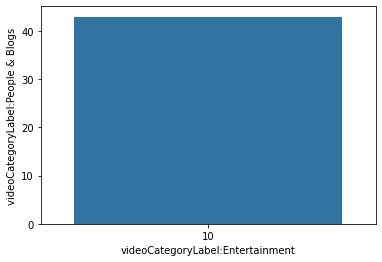

In [29]:
sns.barplot(x=b,y=d)
plt.xlabel("videoCategoryLabel:Entertainment")
plt.ylabel("videoCategoryLabel:People & Blogs")
plt.show()

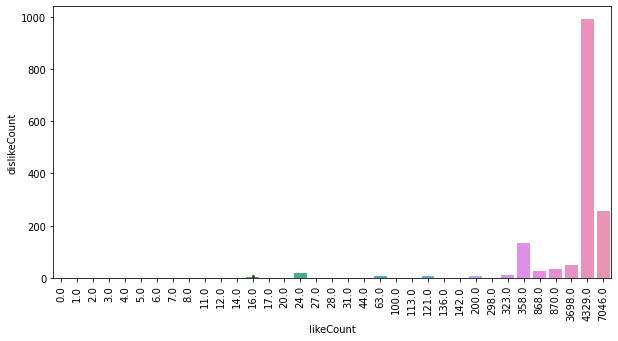

In [30]:
f,ax=plt.subplots(figsize=(10,5))
sns.barplot(x=df["likeCount"],y=df["dislikeCount"],ax=ax)
plt.xticks(rotation=90)
plt.show()

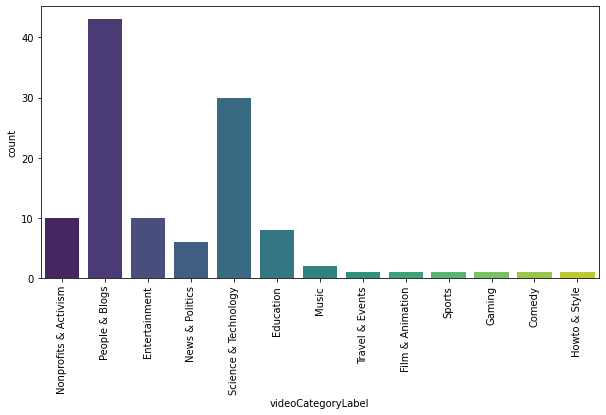

In [31]:
f,ax=plt.subplots(figsize=(10,5))
sns.countplot(x=df["videoCategoryLabel"], palette="viridis")
plt.xticks(rotation=90)
plt.show()

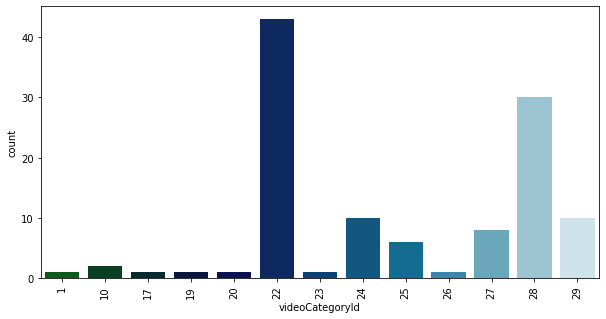

In [32]:
f,ax=plt.subplots(figsize=(10,5))
sns.countplot(x=df["videoCategoryId"], palette="ocean")
plt.xticks(rotation=90)
plt.show()

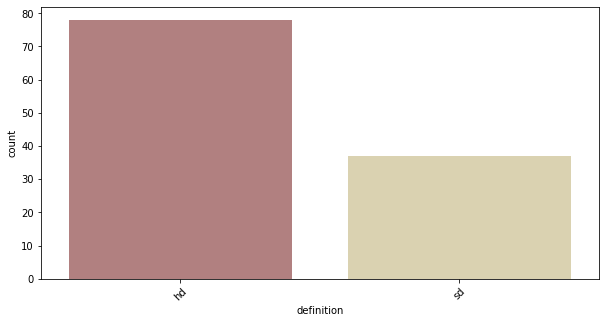

In [33]:

f,ax=plt.subplots(figsize=(10,5))
sns.countplot(x=df["definition"], palette="pink")
plt.xticks(rotation=45)
plt.show()

In [34]:
df["videoCategoryLabel"]

0      Nonprofits & Activism
1             People & Blogs
2             People & Blogs
3              Entertainment
4              Entertainment
               ...          
110            Entertainment
111            Howto & Style
112     Science & Technology
113            Entertainment
114                Education
Name: videoCategoryLabel, Length: 115, dtype: object

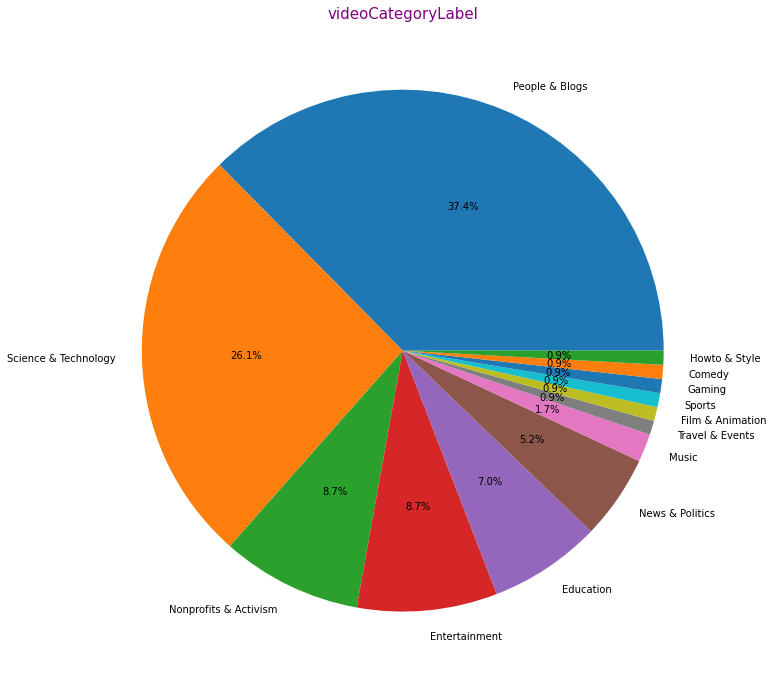

In [35]:
labels = df["videoCategoryLabel"].value_counts().index
sizes = df["videoCategoryLabel"].value_counts()
plt.figure(figsize = (12,12))
plt.pie(sizes, labels=labels, rotatelabels=False, autopct='%1.1f%%')
plt.title('videoCategoryLabel',color = 'purple',fontsize = 15)
plt.show()

In [36]:
df.head()

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
0,0,UCU1_l0ZJyTK_7HZZ3Ruw8Dg,MAPS,pTnk3ziVVRM,2014-01-10T01:24:57.000Z,Psychedelic Horizons Beyond Psychotherapy Work...,Watch the full workshop at http://psychedelics...,29,Nonprofits & Activism,PT1H19M40S,4780,hd,False,1512,8.0,0.0,1.0
1,1,UCLuO2lUqHrPIIpx0hFenV2g,Tink Tink Club,cuJjSeHZIrg,2015-06-18T16:56:04.000Z,Episode 35 - Dr. James Fadiman,Dr. James Fadiman is the father of modern psyc...,22,People & Blogs,PT1H12M34S,4354,sd,False,881,14.0,0.0,3.0
2,2,UCihqrkaOgVMfLNo2W1hSliA,Podcast Bunk,IuyuZfWtGgg,2016-05-01T05:33:13.000Z,#325 Microdosing from The Adam and Dr Drew Sho...,Adam and Dr. Drew are solo today and they open...,22,People & Blogs,PT50M40S,3040,sd,False,67,0.0,1.0,3.0
3,3,UCgbWWPn3VYYzxjffZbfj9GQ,Alan Springwind,cng_ZhQf8iY,2016-01-25T04:48:22.000Z,Microdosing Away The Same Old Blues,Source: https://www.spreaker.com/user/springwi...,24,Entertainment,PT32M21S,1941,hd,False,4,0.0,0.0,0.0
4,4,UCFmLi6X1mojkFZOFngNR9tQ,Drug Education Agency,OpQIQEx7J5A,2014-08-15T10:53:58.000Z,Erschossener Kiffer / Drogen in Mikro-Dosierun...,"Von erschossenen ""Dealern"", von demonstrierend...",24,Entertainment,PT26M32S,1592,hd,False,5465,121.0,6.0,25.0


In [37]:
df[df["commentCount"]>1000]

,Unnamed: 0,channelId,channelTitle,videoId,publishedAt,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,definition,caption,viewCount,likeCount,dislikeCount,commentCount
7,7,UCmrLCXSDScliR7q8AxxjvXg,Black Pigeon Speaks,4ekkXrfmPM8,2016-04-23T09:27:30.000Z,LSD: Microdosing & the SUPERNATURAL,a http://vidmax.com/ original. If you would li...,25,News & Politics,PT13M40S,820,hd,False,108974,4329.0,990.0,3672.0
9,9,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,UGxSZqTZVaU,2015-09-12T13:44:39.000Z,Microdosing LSD or any Psychedelic,How to microdose psychedelics! Everything you ...,28,Science & Technology,PT13M25S,805,hd,False,526243,7046.0,255.0,1706.0
29,29,UCn8V3KNSgDr1Dai77_y8JrQ,PsychedSubstance,54pkxpLiIJc,2016-01-30T15:00:00.000Z,Mescaline Microdose,What's it like to microdose mescaline? Watch t...,24,Entertainment,PT7M45S,465,hd,False,148681,3698.0,49.0,1212.0


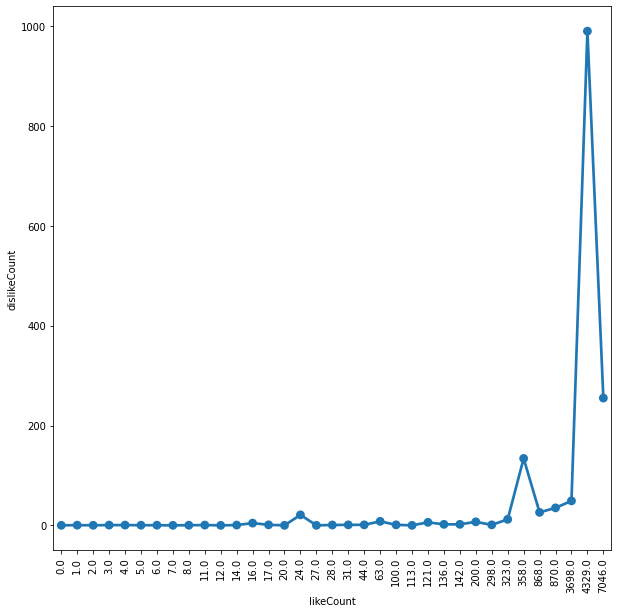

In [38]:
f,ax=plt.subplots(figsize=(10,10))
g=sns.pointplot(data=df, x="likeCount", y="dislikeCount",ax=ax)
g.set_xticklabels(g.get_xticklabels(),rotation = 90)
plt.show()



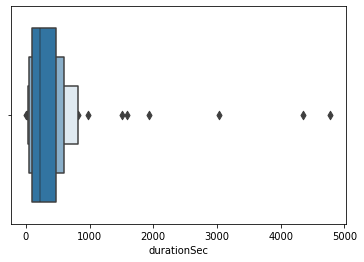

In [39]:
sns.boxenplot(x=df["durationSec"],scale="linear",k_depth="tukey")
plt.show()


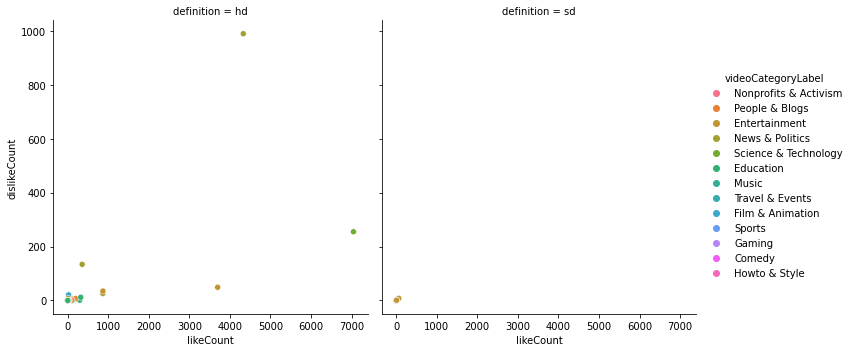

In [40]:
sns.relplot(data=df, x="likeCount", y="dislikeCount", hue="videoCategoryLabel", col="definition")
plt.show()

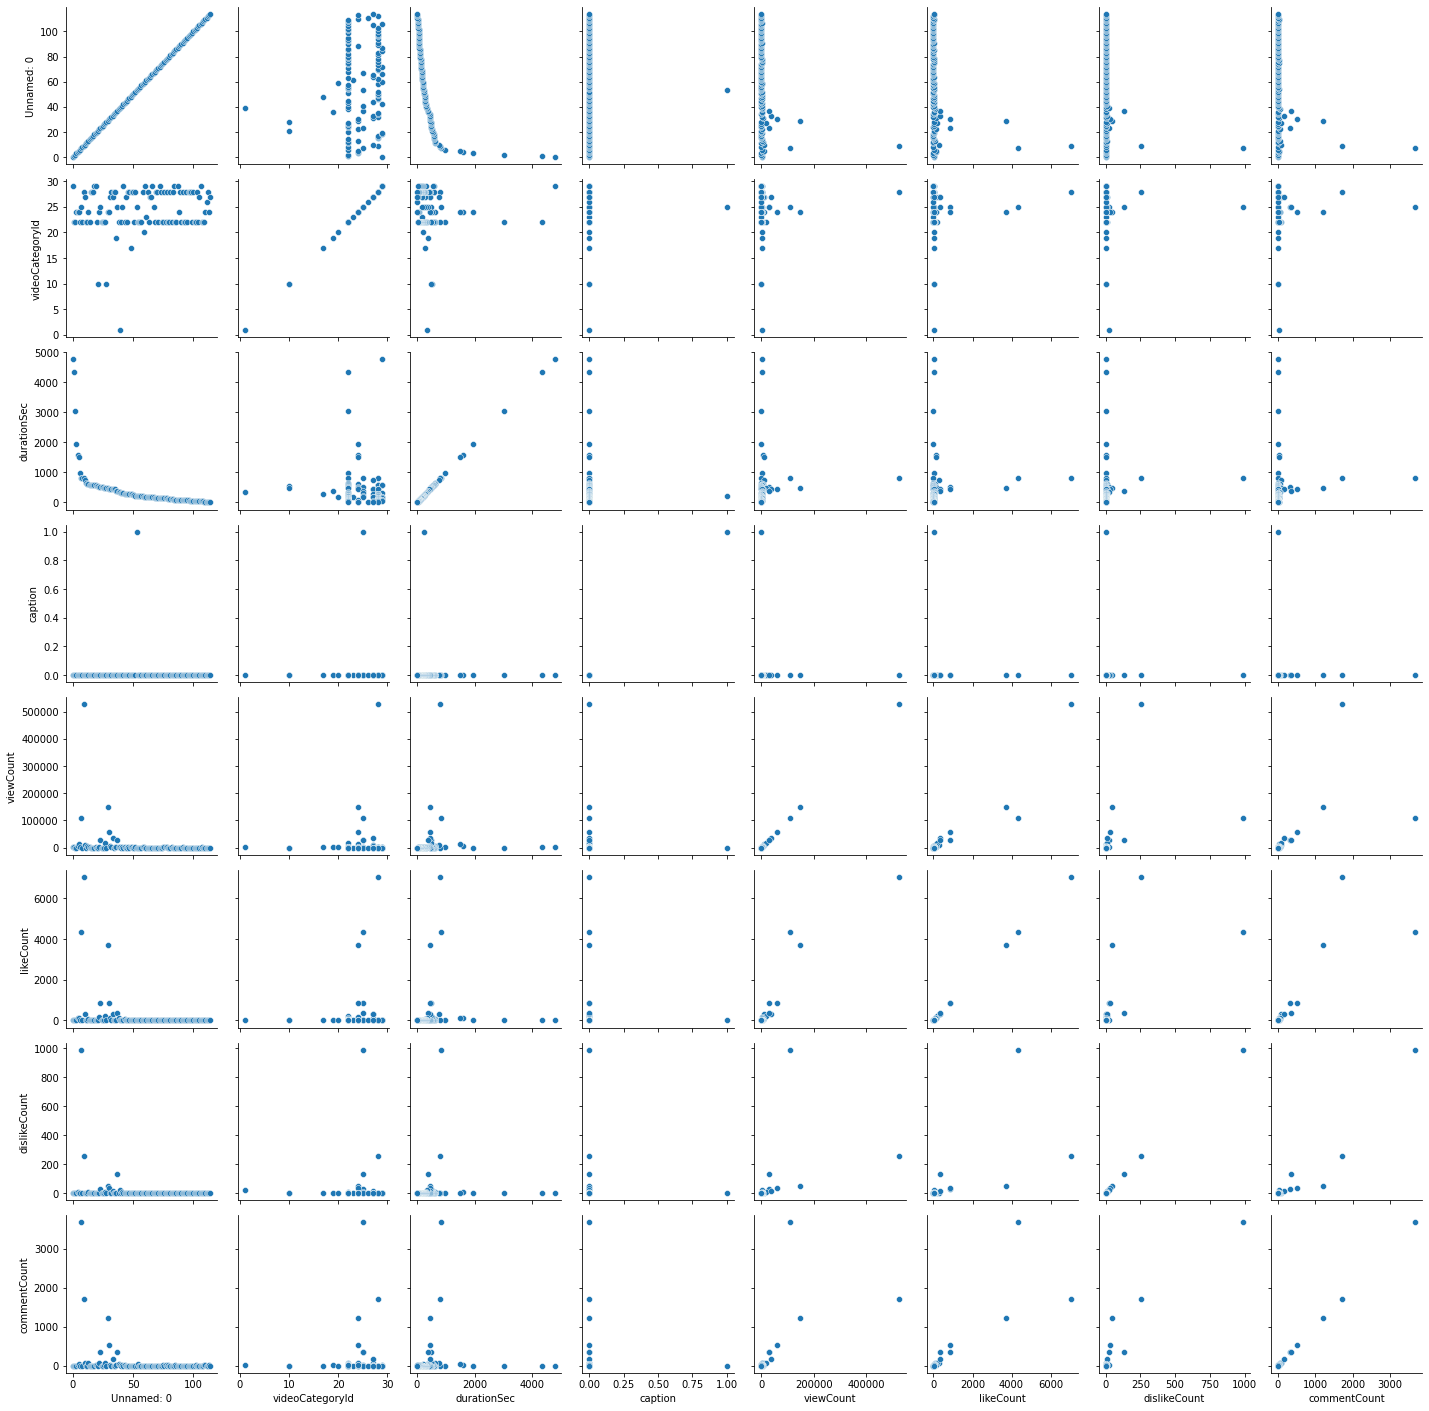

In [41]:
m = sns.PairGrid(df)
m.map(sns.scatterplot)
plt.show()

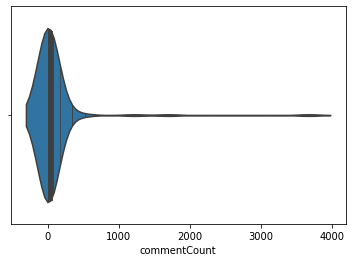

In [42]:
sns.violinplot(x=df["commentCount"],scale="count",inner="stick")
plt.show()

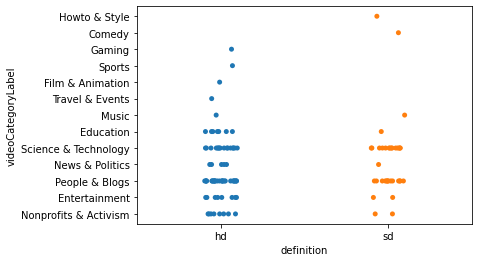

In [43]:
sns.stripplot(data=df, x="definition", y="videoCategoryLabel")
plt.show()